In [1]:
import pandas as pd
import numpy as np  

df = pd.read_csv("P675 DATASET.csv", parse_dates=["Date"]) #importing the dataset and parsing the "Date" column as datetime
df.sample(5) #Displaying 5 ramdom rows

,Date,Open,High,Low,Close,Adj Close,Volume
744,2014-12-17,107.120003,109.839996,106.820000,109.410004,99.839035,53411800
1773,2019-01-22,156.410004,156.729996,152.619995,153.300003,149.995956,30394000
1944,2019-09-25,218.550003,221.500000,217.139999,221.029999,218.858505,21903400
696,2014-10-09,101.540001,102.379997,100.610001,101.019997,91.784966,77376500
1934,2019-09-11,218.070007,223.710007,217.729996,223.589996,221.393372,44289600


In [2]:
df.info() #information about the dataset

<class 'pandas.DataFrame'>
RangeIndex: 2011 entries, 0 to 2010
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       2011 non-null   datetime64[us]
 1   Open       2011 non-null   float64       
 2   High       2011 non-null   float64       
 3   Low        2011 non-null   float64       
 4   Close      2011 non-null   float64       
 5   Adj Close  2011 non-null   float64       
 6   Volume     2011 non-null   int64         
dtypes: datetime64[us](1), float64(5), int64(1)
memory usage: 110.1 KB


In [3]:
df.isnull().sum() #checking for null values in the dataset

Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64

In [4]:
df.duplicated().sum() #checking for duplicates in the dataset

np.int64(0)

In [5]:
df.set_index('Date', inplace=True) #setting the "Date" column as the index of the dataframe

In [6]:
close_col = df.pop('Close')
df['Close'] = close_col
df.sample(5)

,Open,High,Low,Adj Close,Volume,Close
Date,,,,,,
2015-08-10,116.529999,119.989998,116.529999,110.634941,54951600,119.720001
2019-06-13,194.699997,196.789993,193.600006,191.514923,21674600,194.149994
2012-08-15,90.185715,90.571426,89.678574,78.209335,64335600,90.118568
2013-09-12,66.928574,67.914284,66.572861,59.999676,101012800,67.527145
2013-10-09,69.234283,69.684288,68.325714,61.764019,75431300,69.512856


# Target column visualization

In [7]:
import plotly.express as px

fig = px.line(df, x=df.index, y='Close', title='Close Price')
fig.show()

# Feature Selection

In [8]:
fig = px.imshow(df.corr(),text_auto='.2f',color_continuous_scale='Viridis',title='Correlation Heatmap')
fig.update_layout(width=700,height=600)
fig.update_xaxes(tickangle=90)
fig.show()

### Here we Are Select close and volume features olny 
- they are almost duplicates
- add noise/redundancy
- increase complexity without much benefit

In [9]:
data = df[['Close', 'Volume']]
data.head()

,Close,Volume
Date,,
2012-01-03,58.747143,75555200
2012-01-04,59.062859,65005500
2012-01-05,59.718571,67817400
2012-01-06,60.342857,79573200
2012-01-09,60.247143,98506100


# Scale Data

In [10]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data)
scaled_data[:5]

array([[0.01254462, 0.17579087],
       [0.01388393, 0.14690088],
       [0.01666555, 0.15460117],
       [0.01931386, 0.18679402],
       [0.01890783, 0.23864112]])

# Create Sequences

In [11]:
x = []
y = []

sequence_length = 30

for i in range(sequence_length, len(scaled_data)):
    
    x.append(scaled_data[i-sequence_length:i])
    
    # Close column is first column
    y.append(scaled_data[i, 0])

x = np.array(x)
y = np.array(y)

In [12]:
print(x.shape)
print(y.shape)

(1981, 30, 2)
(1981,)


# Train Test Split(multivariate forecasting)

In [13]:
split = int(len(x) * 0.8)

x_train_m = x[:split]
x_test_m = x[split:]

y_train_m= y[:split]
y_test_m = y[split:]

# For Univariate Forecasting

In [14]:
u_data = df["Close"]
u_data.head()

Date
2012-01-03    58.747143
2012-01-04    59.062859
2012-01-05    59.718571
2012-01-06    60.342857
2012-01-09    60.247143
Name: Close, dtype: float64

In [15]:
fig = px.line(u_data, title='Close Price')
fig.show()

# Check Stationarity

In [17]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(u_data)

print('ADF Statistic:', result[0])
print('p-value:', result[1])

ADF Statistic: 1.2193701254377995
p-value: 0.9961170178032009


- series is not stationary we have to perform differencing to make it stationary

In [22]:
data_diff = u_data.diff().dropna() #differencing the data to make it stationary

In [24]:
result = adfuller(data_diff)
print('ADF Statistic:',np.round(result[0], 4))
print('p-value:', np.round(result[1], 4))

ADF Statistic: -13.6255
p-value: 0.0


- d=1
- So your ARIMA model will use: ARIMA(p,1,q)

# Plot ACF & PACF

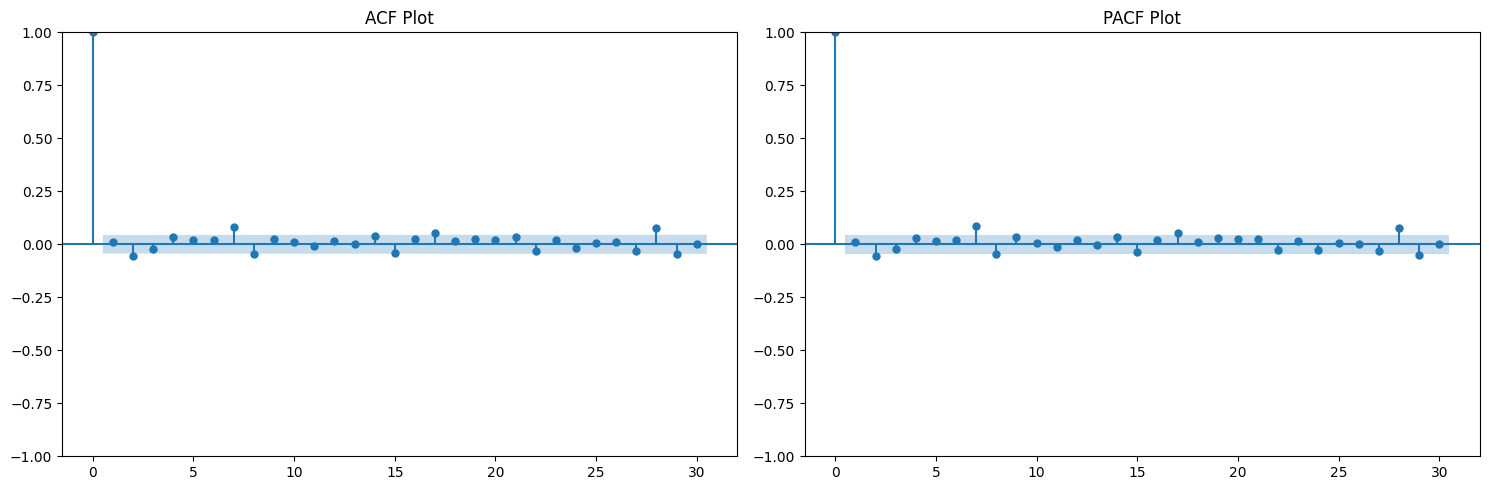

In [26]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(15,5))

# ACF Plot
plot_acf(data_diff, lags=30, ax=axes[0])
axes[0].set_title("ACF Plot")

# PACF Plot
plot_pacf(data_diff, lags=30, ax=axes[1])
axes[1].set_title("PACF Plot")

plt.tight_layout()
plt.show()

## ACF and PACF plots look very clean.
- Almost all spikes are inside the confidence interval, which means:
    - your differenced series is already close to white noise
    - there is very little autocorrelation left
### We try with :
- ARIMA(0,1,0)
- ARIMA(1,1,0)
- ARIMA(0,1,1)
- ARIMA(1,1,1)

# Train Test Split (Univariate forecasting)

In [27]:
train_size = int(len(u_data) * 0.8)

train_u = data[:train_size]
test_u = data[train_size:]